# 📊 Data Analysis Notebook

## Objective
Explore the cleaned food price data to discover patterns, trends, and insights that will guide hypothesis testing and machine learning predictions.

## Analysis Approach
We follow a systematic exploratory data analysis (EDA) approach:
1. **Descriptive Statistics**: Summarise central tendencies and spread of the data
2. **Distribution Analysis**: Understand the shape and characteristics of variables
3. **Comparative Analysis**: Compare inflation across countries and time periods
4. **Correlation Analysis**: Identify relationships between variables
5. **Time Series Analysis**: Detect trends and seasonal patterns

## Questions We'll Answer
1. 📈 How have food prices changed over time globally?
2. 🌍 Which countries have the highest/lowest inflation rates?
3. 📅 Are there seasonal patterns in food prices?
4. 🔗 What variables are correlated with each other?

## Prerequisites
Run `Data_Cleaning.ipynb` first to generate the cleaned dataset.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## Step 2: Load Data

In [2]:
df = pd.read_csv('../data/cleaned/food_prices_cleaned.csv', parse_dates=['date'])

print("✅ Data Loaded!")
print(f"📊 Size: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"📅 Period: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
print(f"🌍 Countries: {df['country'].nunique()}")

✅ Data Loaded!
📊 Size: 4,798 rows, 14 columns
📅 Period: January 2007 to October 2023
🌍 Countries: 25


In [3]:
df.head()

,open,high,low,close,inflation,country,iso3,date,year,month,quarter,price_range,price_change,price_change_pct
0,0.53,0.54,0.53,0.53,NaN,Afghanistan,AFG,2007-01-01,2007,1,1,0.01,0.00,0.0000
1,0.53,0.54,0.53,0.53,NaN,Afghanistan,AFG,2007-02-01,2007,2,1,0.01,0.00,0.0000
2,0.54,0.54,0.53,0.53,NaN,Afghanistan,AFG,2007-03-01,2007,3,1,0.01,-0.01,-1.8519
3,0.53,0.55,0.53,0.55,NaN,Afghanistan,AFG,2007-04-01,2007,4,2,0.02,0.02,3.7736
4,0.56,0.57,0.56,0.57,NaN,Afghanistan,AFG,2007-05-01,2007,5,2,0.01,0.01,1.7857


## Step 3: Summary Statistics

In [4]:
numerical_cols = ['open', 'high', 'low', 'close', 'inflation', 'price_range', 'price_change_pct']
df[numerical_cols].describe().round(3)

,open,high,low,close,inflation,price_range,price_change_pct
count,4734.000,4734.000,4734.000,4734.000,4434.000,4734.000,4734.000
mean,1.492,1.536,1.451,1.492,14.692,0.085,0.114
std,4.652,4.883,4.439,4.633,35.910,0.502,3.259
min,0.010,0.010,0.010,0.010,-31.470,0.000,-33.333
25%,0.740,0.750,0.720,0.740,-0.488,0.020,-1.096
50%,0.960,0.980,0.950,0.960,5.360,0.030,0.000
75%,1.100,1.120,1.078,1.100,16.372,0.050,1.149
max,102.460,106.480,94.420,94.420,363.100,18.390,33.611


In [5]:
print("📊 KEY INSIGHTS")
print("="*50)
print(f"Average price index: {df['close'].mean():.2f}")
print(f"Average inflation: {df['inflation'].mean():.2f}%")
print(f"Highest inflation: {df['inflation'].max():.2f}%")
print(f"Lowest inflation: {df['inflation'].min():.2f}%")

📊 KEY INSIGHTS
Average price index: 1.49
Average inflation: 14.69%
Highest inflation: 363.10%
Lowest inflation: -31.47%


## Step 4: Country Rankings

In [6]:
print("🔥 TOP 5 COUNTRIES - HIGHEST INFLATION")
print("="*50)
top5 = df.groupby('country')['inflation'].mean().sort_values(ascending=False).head(5)
for rank, (country, val) in enumerate(top5.items(), 1):
    print(f"   {rank}. {country}: {val:.2f}%")

print("\n🌟 TOP 5 COUNTRIES - LOWEST INFLATION")
print("="*50)
bottom5 = df.groupby('country')['inflation'].mean().sort_values().head(5)
for rank, (country, val) in enumerate(bottom5.items(), 1):
    print(f"   {rank}. {country}: {val:.2f}%")

🔥 TOP 5 COUNTRIES - HIGHEST INFLATION
   1. Sudan: 65.87%
   2. South Sudan: 62.92%
   3. Lebanon: 56.40%
   4. Syrian Arab Republic: 41.70%
   5. Haiti: 15.88%

🌟 TOP 5 COUNTRIES - LOWEST INFLATION
   1. Iraq: 1.50%
   2. Congo, Rep.: 1.50%
   3. Guinea-Bissau: 2.37%
   4. Cameroon: 2.79%
   5. Niger: 3.86%


## Step 5: Distribution Analysis

Understanding how our variables are distributed is a prerequisite for choosing the right statistical tests and for spotting anomalies. If the data follow a normal (bell-curve) distribution we can use parametric tests; if they are heavily skewed or contain extreme outliers we must reach for non-parametric alternatives.

In this step we examine four distributions. First, the **price distribution** tells us whether food price indices cluster around a central value or spread out asymmetrically. Second, the **inflation distribution** reveals the full range of year-over-year price changes, including episodes of deflation and hyperinflation. Third, the **volatility distribution** (price range) shows how much prices fluctuate within a single month across our 25 countries. Fourth, **yearly boxplots** let us see whether the shape of the inflation distribution has shifted over time.

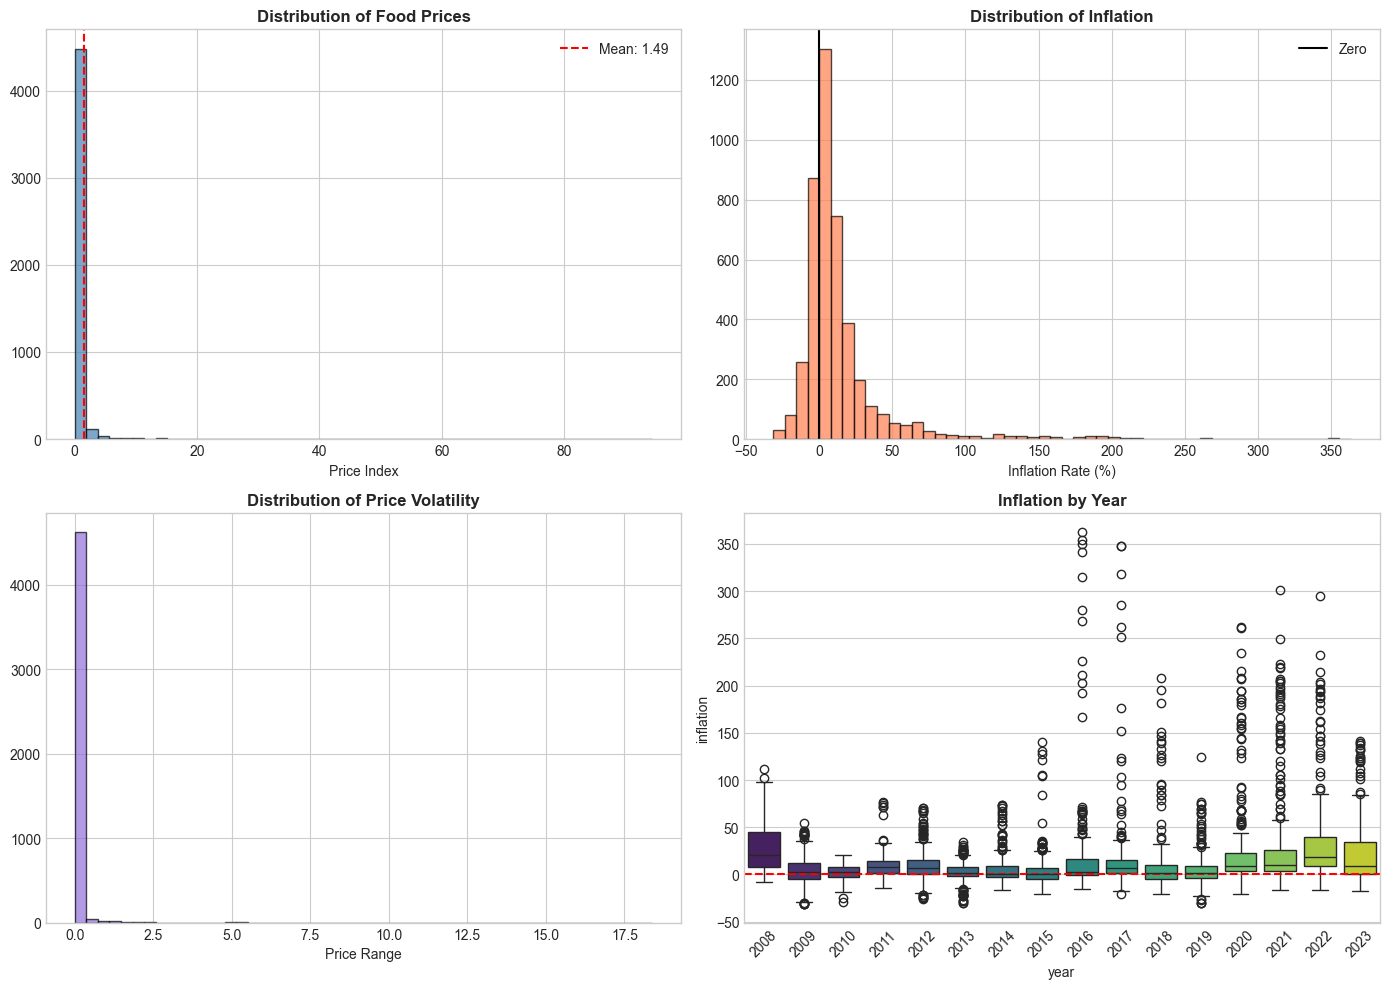

💾 Saved: outputs/figures/distribution_analysis.png


In [7]:
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(df['close'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Food Prices', fontweight='bold')
axes[0, 0].set_xlabel('Price Index')
axes[0, 0].axvline(df['close'].mean(), color='red', linestyle='--', label=f'Mean: {df["close"].mean():.2f}')
axes[0, 0].legend()

# Inflation distribution
axes[0, 1].hist(df['inflation'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribution of Inflation', fontweight='bold')
axes[0, 1].set_xlabel('Inflation Rate (%)')
axes[0, 1].axvline(0, color='black', linestyle='-', label='Zero')
axes[0, 1].legend()

# Volatility distribution
axes[1, 0].hist(df['price_range'], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1, 0].set_title('Distribution of Price Volatility', fontweight='bold')
axes[1, 0].set_xlabel('Price Range')

# Inflation by year
sns.boxplot(data=df[df['inflation'].notna()], x='year', y='inflation', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Inflation by Year', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/figures/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: outputs/figures/distribution_analysis.png")

## Step 6: Time Series Analysis

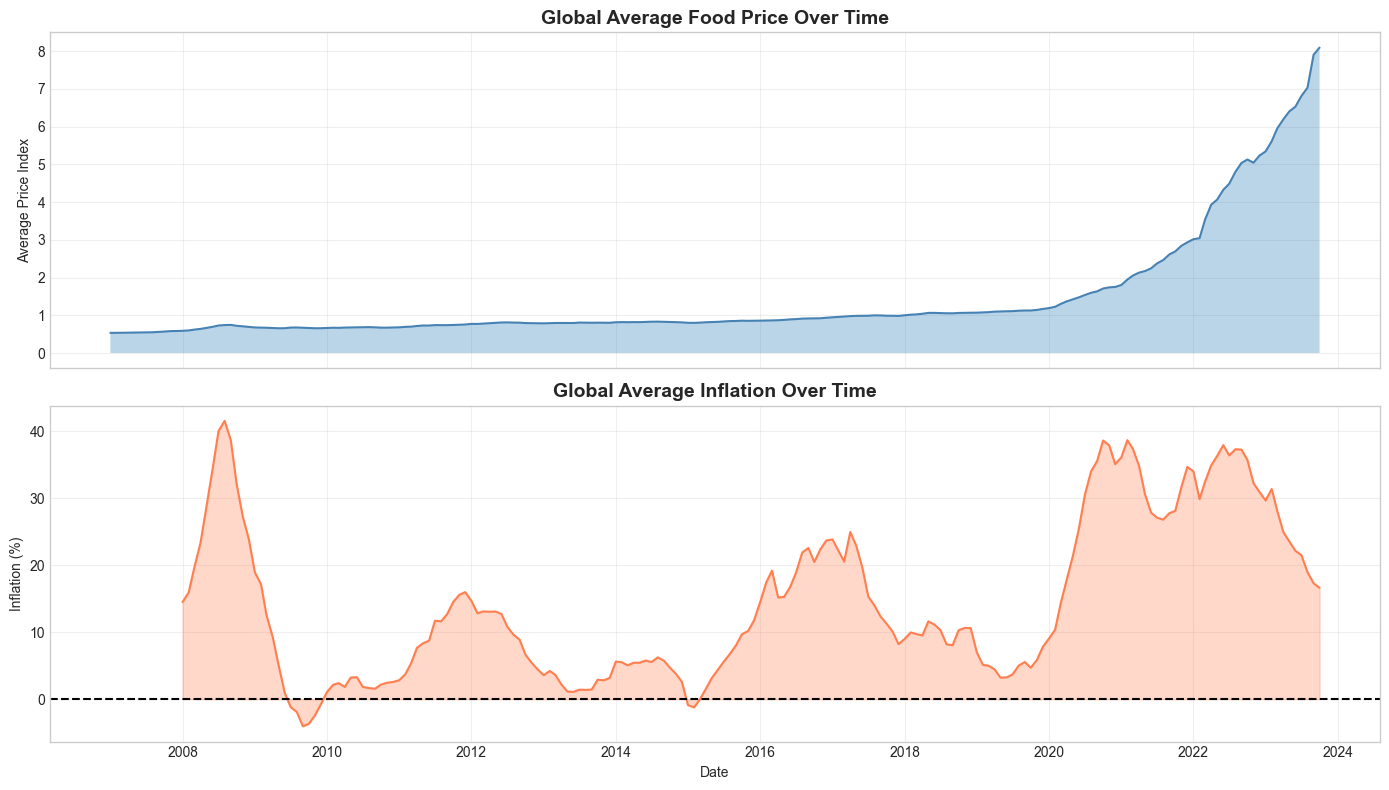

💾 Saved: outputs/figures/time_series_analysis.png


In [8]:
monthly_avg = df.groupby('date').agg({'close': 'mean', 'inflation': 'mean'}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_avg['date'], monthly_avg['close'], color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly_avg['date'], monthly_avg['close'], alpha=0.3)
axes[0].set_title('Global Average Food Price Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Price Index')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_avg['date'], monthly_avg['inflation'], color='coral', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].fill_between(monthly_avg['date'], monthly_avg['inflation'], alpha=0.3, color='coral')
axes[1].set_title('Global Average Inflation Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Inflation (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: outputs/figures/time_series_analysis.png")

## Step 7: Country Comparison

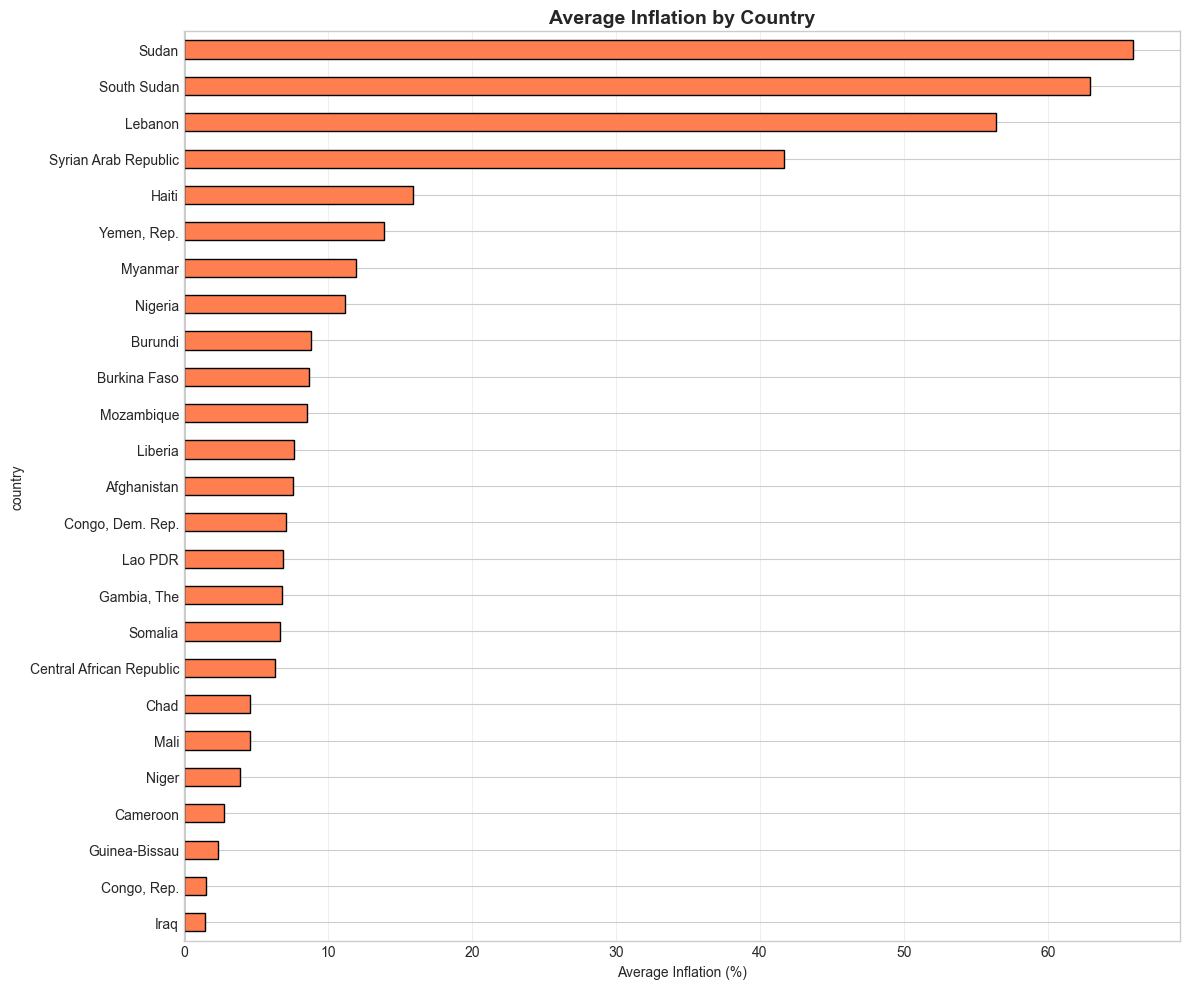

💾 Saved: outputs/figures/country_comparison.png


In [9]:
country_inflation = df.groupby('country')['inflation'].mean().sort_values(ascending=True).dropna()

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['coral' if x > 0 else 'steelblue' for x in country_inflation]
country_inflation.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Average Inflation by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Inflation (%)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/country_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: outputs/figures/country_comparison.png")

## Step 8: Correlation Analysis

Correlation analysis measures the strength and direction of linear (or monotonic) relationships between pairs of numeric variables. Coefficients range from −1 to +1. Values between roughly 0.7 and 1.0 (or −0.7 to −1.0) indicate a strong relationship, values in the 0.4 to 0.7 range are moderate, and anything below about 0.4 is considered weak. Values near zero suggest little or no linear association.

A crucial caveat: **correlation does not imply causation**. Two variables may move together because a hidden third factor drives both, or the link may be purely coincidental. We use correlation here as a screening tool; it tells us which relationships are worth investigating further, not that one variable directly causes changes in another.

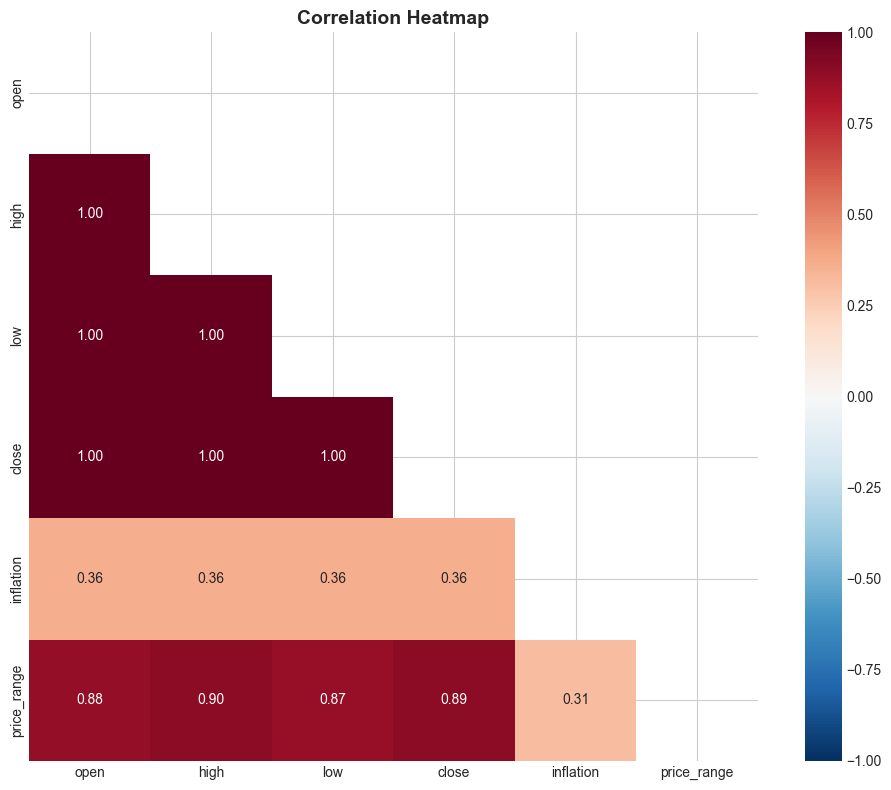

💾 Saved: outputs/figures/correlation_matrix.png


In [10]:
correlation_cols = ['open', 'high', 'low', 'close', 'inflation', 'price_range']
correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: outputs/figures/correlation_matrix.png")

## Step 9: Seasonal Patterns

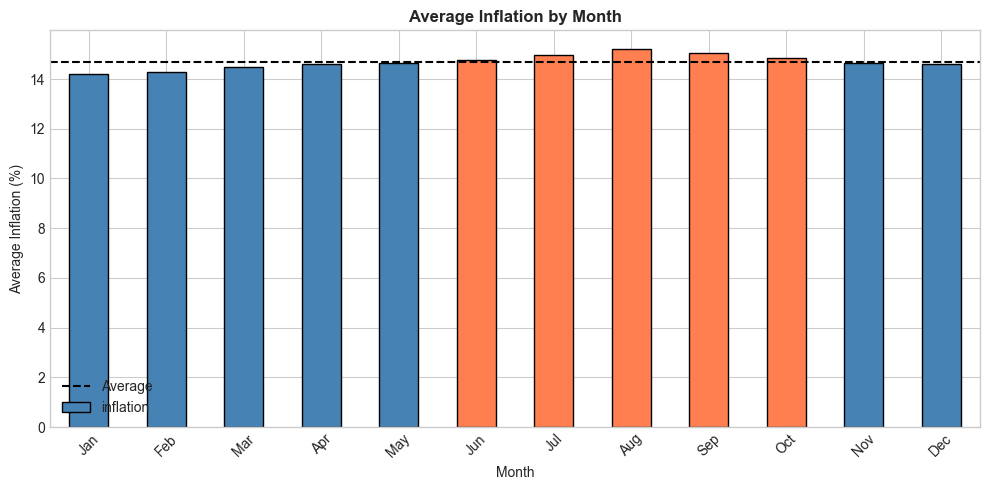

💾 Saved: outputs/figures/seasonal_analysis.png


In [11]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg_season = df.groupby('month')['inflation'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if x > monthly_avg_season.mean() else 'steelblue' for x in monthly_avg_season]
monthly_avg_season.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Average Inflation by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Inflation (%)')
ax.axhline(y=monthly_avg_season.mean(), color='black', linestyle='--', label='Average')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/seasonal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: outputs/figures/seasonal_analysis.png")

## Step 10: Interactive Visualisation

In [12]:
fig = px.line(
    df, x='date', y='close', color='country',
    title='Food Price Index by Country Over Time',
    labels={'close': 'Price Index', 'date': 'Date', 'country': 'Country'}
)
fig.update_layout(
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=-0.3, xanchor='center', x=0.5),
    hovermode='x unified'
)
fig.show()
print("💡 Tip: Click country names in legend to show/hide them!")

💡 Tip: Click country names in legend to show/hide them!


## Summary and Key Takeaways

Our exploratory analysis revealed four headline findings. First, food prices have followed a **steady upward trend** throughout the sixteen-year study period, which raises growing concerns about food affordability, especially for lower-income populations. Second, inflation rates **vary dramatically between countries**, confirming that local conditions such as agricultural productivity, trade policy, and currency stability play a decisive role in price outcomes. Third, higher absolute price levels tend to go hand-in-hand with greater price **volatility**, suggesting that policies aimed at stabilising markets could also help moderate inflation. Fourth, mild **seasonal patterns** are visible in monthly averages, hinting that agricultural cycles may influence food prices in a predictable way.

Through this exploration we identified the variables and relationships worth testing with formal statistics, generated the hypotheses that the next notebook will validate, created a suite of visualisations for stakeholder communication, and earmarked features that are likely to be informative for machine learning prediction models.

The five charts produced in this notebook (`distribution_analysis.png`, `time_series_analysis.png`, `country_comparison.png`, `correlation_matrix.png`, and `seasonal_analysis.png`) are saved in `outputs/figures/` and are referenced in both the Streamlit dashboard and the project README.

The patterns we have observed so far are suggestive, but they need **statistical validation** to confirm they are not simply the result of random chance.

**Next step:** Open `Hypothesis_Testing.ipynb` to statistically validate these patterns!